# 04 상관관계와 산점도 분석

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [11]:
diamonds_sample = diamonds.sample(1000, random_state=42)
diamonds_sample.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1388,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
50052,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
41645,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
42377,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
17244,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


### 산점도 - scatter (캐럿이 가격에 미치는 영향)

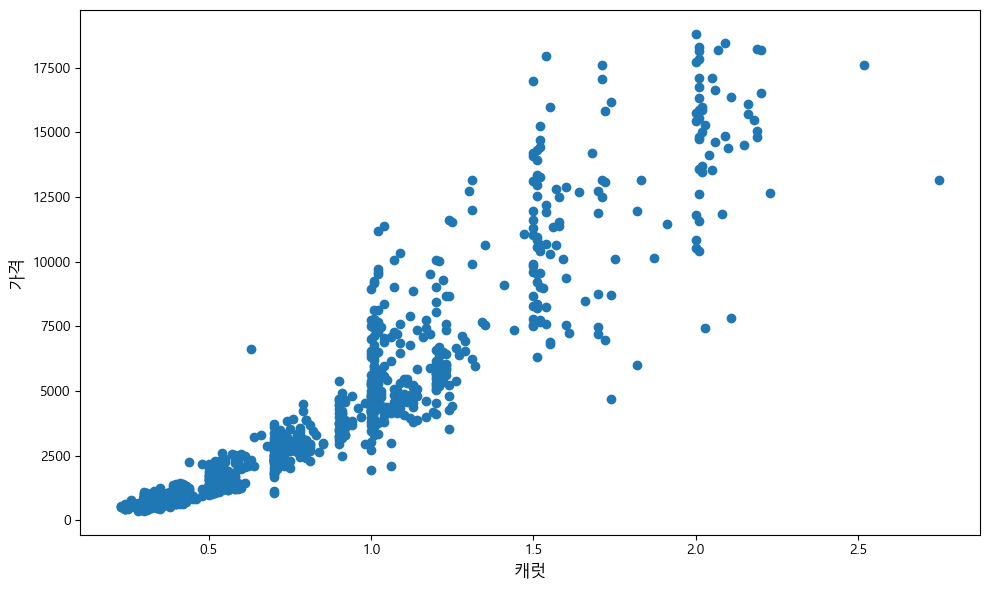

상관계수 : 0.922


In [12]:
# 산점도.. scatter   캐럿이 가격에 미치는 영향
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(diamonds_sample['carat'], diamonds_sample['price'])
ax.set_xlabel('캐럿',fontsize=12)
ax.set_ylabel('가격',fontsize=12)
plt.tight_layout()
plt.show()

# 상관계수 계산
corr = diamonds['carat'].corr(diamonds['price'])
print(f'상관계수 : { corr:.3f}')

<Axes: xlabel='carat', ylabel='price'>

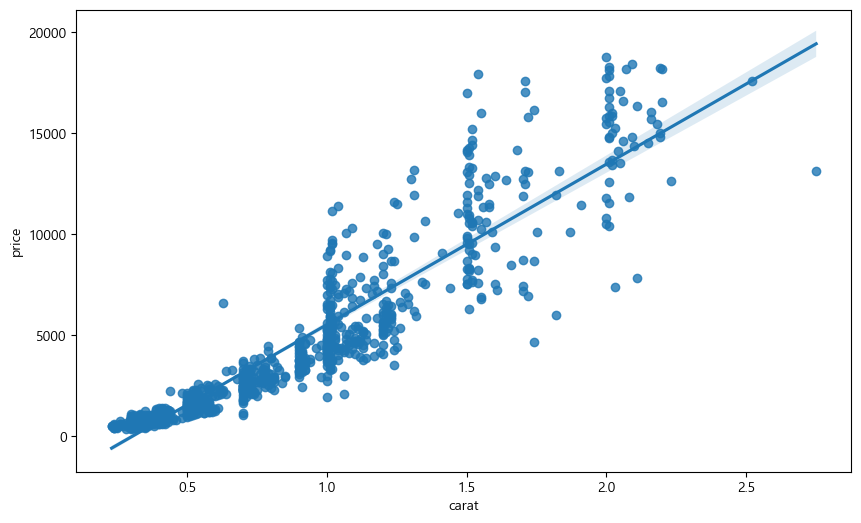

In [13]:
# Regplot : 회귀선
# 캐럿을 기준으로 적정 가격을 예측 할수 있나?
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(data=diamonds_sample, x='carat', y='price', ax=ax)

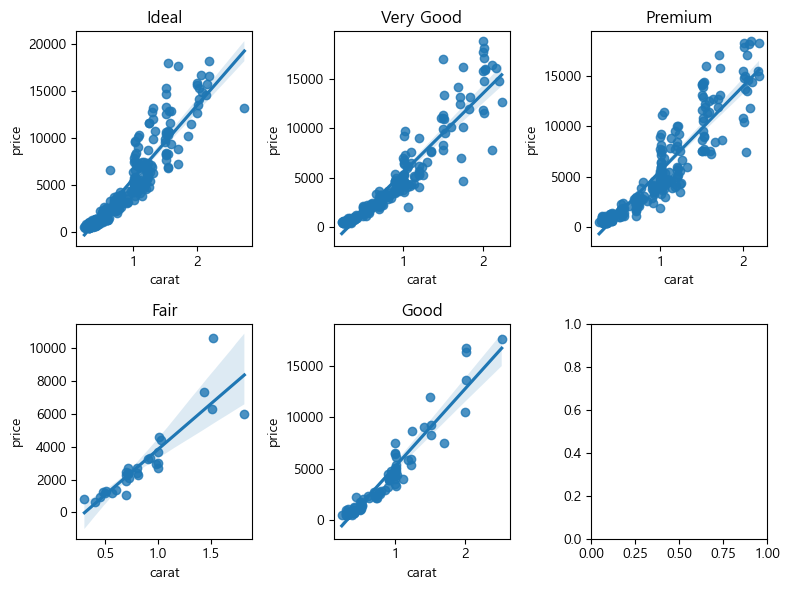

In [14]:
# 다이아몬드 등급(커팅)에 따라 가격패턴이 다른가?
fig, ax = plt.subplots(2,3,figsize=(8,6))
for idx, cut in enumerate( diamonds_sample['cut'].unique() ):
    sns.regplot(data = diamonds_sample[ diamonds_sample['cut'] == cut ],
                    x='carat',y='price',ax= ax[idx // 3,idx % 3])
    ax[idx // 3,idx % 3].set_title(cut)   
plt.tight_layout()
plt.show()    

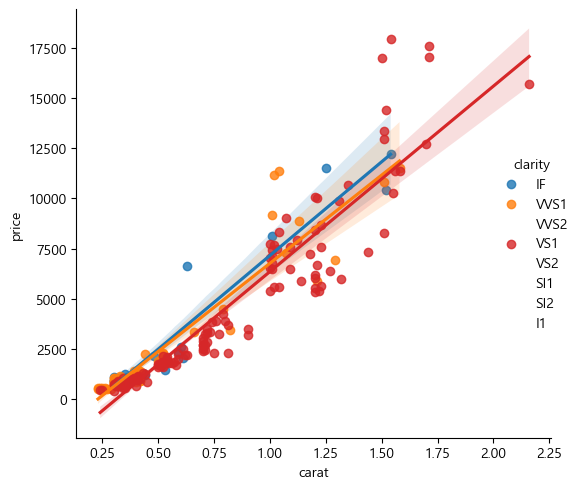

In [15]:
clarity_subset = diamonds_sample[diamonds_sample['clarity'].isin(['IF','VVS1','VS1'])]
g = sns.lmplot(data = clarity_subset, x='carat',y='price', hue='clarity')
plt.tight_layout()
plt.show()

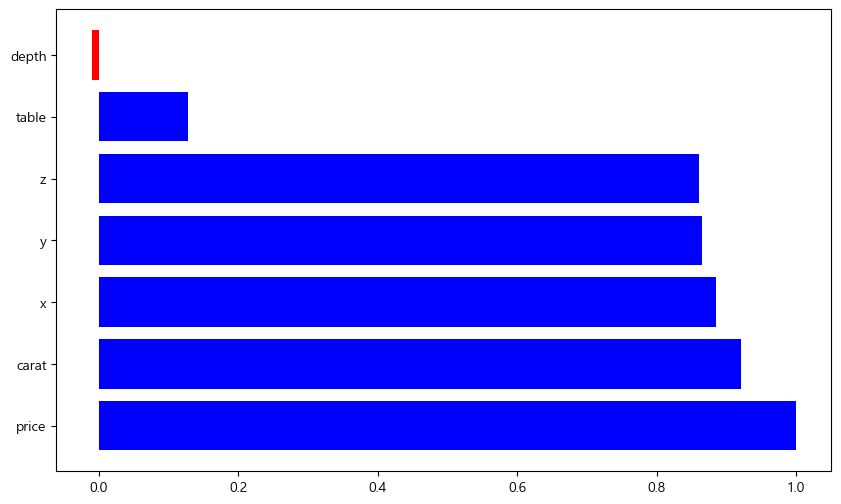

In [25]:
# 어떤 속성이 가격에 가장 큰 영향을 미칠까?
# 수치형 변수들의 상관계수를 계산


numeric_cols = list(diamonds.describe().columns)
numeric_cols.remove('price')
# numeric_cols = pd.Index(numeric_cols)
correlation = diamonds[numeric_cols + ['price']].corr()['price'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue' if x > 0 else 'red' for x in correlation.values]
bars = ax.barh(correlation.index, correlation.values, color = colors)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_15176\449281358.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


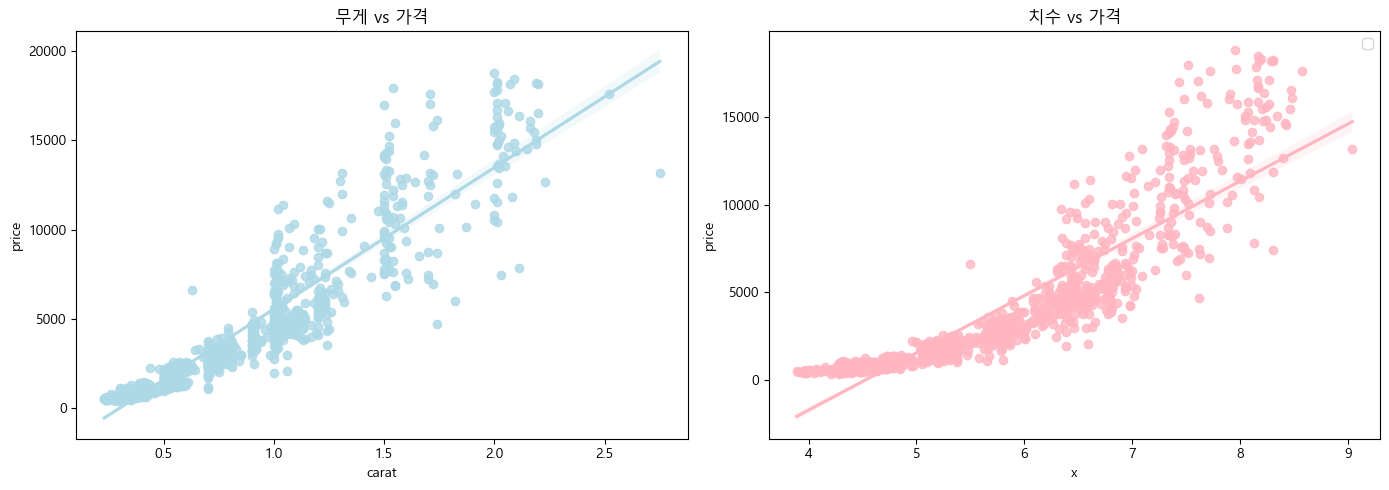

In [ ]:
# 상관관계 vs 인과관계

# 무게와 x 차수의 관계
fig, axes = plt.subplots(1,2,figsize=(14,5))

# 좌측 Carat vs Price
sns.regplot(data = diamonds_sample, x='carat', y='price', ax=axes[0], color='lightblue')
axes[0].set_title('무게 vs 가격')

# 우측 X(치수) vs Price
sns.regplot(data = diamonds_sample, x='x', y='price', ax=axes[1], color='lightpink')
axes[1].set_title('치수 vs 가격')

plt.tight_layout()
plt.legend()

# 무게가 증가하면 치수도 증가하는 관계 (치수 vs 가격 허위 상관관계)
# 추론할 때 불필요한 계수 즉 변수임
# 따라서 머신러닝 할 때는 학습에서 제외시켜야 함.

In [31]:
diamonds_sample[numeric_cols].corr()

,carat,depth,table,x,y,z
carat,1.000000,-0.078646,0.200590,0.980120,0.979933,0.978572
depth,-0.078646,1.000000,-0.344625,-0.127685,-0.127643,-0.009381
table,0.200590,-0.344625,1.000000,0.218992,0.212593,0.177378
x,0.980120,-0.127685,0.218992,1.000000,0.998434,0.992165
y,0.979933,-0.127643,0.212593,0.998434,1.000000,0.992446
z,0.978572,-0.009381,0.177378,0.992165,0.992446,1.000000
